version 1 (Last Updated 2026/03/31)

# Problem 1: Principal Component Analysis (25\%)



### Introduction

Principal component analysis (PCA) is a technique that transforms high-dimension data into lower dimensions while retaining as much information as possible.

We do dimensionality reduction to convert the high $d$-dimensional dataset into $k$-dimensional data where $k<d$. It's possible for data to have a significantly larger variance on one axis compared to another. Typically, a higher variance suggests more information is present in that direction. Consequently, we can disregard dimensions with less variance since they contain less information.

In [37]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import os

### Dataset

ORL Face Data The face data set used in this question is the ORL database of faces. Each face is a 56x46 array of pixels that has been flattened into a 1D-vector of length 2576. (Note: prior to plotting any images, you must reshape the image back into a 2D array of dimensions 56x46. See the last cell in the Introduction section for an example of how to do this).


- `X_train.csv`: each of the 360 lines contains data for a 56 × 46 face image.
- `Y_train.csv`: each of the 360 lines contains the label for the corresponding line in X\_train.csv.
- `X_test.csv`: each of the 40 lines contains data for a 56 x 46 face image.
- `Y_test.csv`: labels for face images in X\_test.csv.

In [38]:
# Upload the data to your google drive from Canvas then mount to the folder
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

ModuleNotFoundError: No module named 'google.colab'

Use the command `%ls` ([IPython built-in magic command](https://ipython.readthedocs.io/en/stable/interactive/magics.html)) to locate your folder.



In [ ]:
folder_path = "data_hw1/"

%ls -l data_hw1/

ls: cannot access 'drive/MyDrive/EE443_2024/hw1/': No such file or directory


In [ ]:
def load_data(filename):
    data = []
    with open(filename, 'r') as f:
        lines = csv.reader(f, delimiter=',')
        for line in lines:
            data.append([float(x) for x in line])
    data = np.array(data)
    print(f'Loaded {filename} with {len(data)} samples (shape: {data.shape})')
    return data

def vis_data_2d(data):
    # visualize a 2d data as an image
    assert len(data.shape) == 2
    plt.figure(figsize=(4, 2))
    plt.imshow(data, cmap='gray')
    plt.axis('off')

In [ ]:
x_train = load_data(folder_path + "data/p1/X_train.csv")
x_test = load_data(folder_path + "data/p1/X_test.csv")
y_train = load_data(folder_path + "data/p1/Y_train.csv")
y_test = load_data(folder_path + "data/p1/Y_test.csv")

Loaded drive/MyDrive/EE443_2024/hw1/data/p1/X_train.csv with 360 samples (shape: (360, 2576))
Loaded drive/MyDrive/EE443_2024/hw1/data/p1/X_test.csv with 40 samples (shape: (40, 2576))
Loaded drive/MyDrive/EE443_2024/hw1/data/p1/Y_train.csv with 360 samples (shape: (360, 1))
Loaded drive/MyDrive/EE443_2024/hw1/data/p1/Y_test.csv with 40 samples (shape: (40, 1))


In [ ]:
# Visualize an image
first_data_sample_in_train_img = x_train[0].reshape((56, 46))
first_data_sample_in_train_label = y_train[0][0]
vis_data_2d(first_data_sample_in_train_img)
print(f"ID: {int(first_data_sample_in_train_label)}")

### Principal Component Analysis

1-(a). Implementation of `my_pca()`

1. (Data Standardization) Compute the mean face $\bar{x}$ of the 360 training faces, and subtract it from each training data point:

    \begin{align}
        \bar{x} = \frac{1}{N}\sum^{N}_{n=1} x_n
    \end{align}

2. (Covariance Matrix) Compute the covariance matrix $S$ using np.cov()::
    \begin{align}
        S = \frac{1}{N}\sum^{N}_{n=1} (x_n - \bar{x})(x_n - \bar{x})^T.
    \end{align}

3. (Eigen-Decomposition) Perform eigen-decomposition on $S$ using \texttt{np.linalg.eigh()} to obtain eigenvalues $\Lambda$ and eigenvectors $V$:
    \begin{align}
        S = V \cdot \Lambda \cdot V^T &= \begin{bmatrix}
                                        \vdots & \vdots & & \vdots \\
                                        v_1 & v_2 & \dots & v_d \\
                                        \vdots & \vdots & & \vdots \\
                                        \end{bmatrix}
                                        \begin{bmatrix}
                                        \lambda_1 & 0 & \dots & 0 \\
                                        0 & \lambda_2 & \dots & 0 \\
                                        \vdots & \vdots & \ddots & \vdots \\
                                        0 & 0 & \dots & \lambda_d
                                        \end{bmatrix}
                                        \begin{bmatrix}
                                        \dots & v_1 & \dots \\
                                        \dots & v_2 & \dots \\
                                        & \vdots &  \\
                                        \dots & v_d & \dots \\
                                        \end{bmatrix}\\
        &= \begin{bmatrix}
            \lambda_1 v_1 & \lambda_1 v_1 & \dots & \lambda_d v_d
        \end{bmatrix}
        \begin{bmatrix}
            v_1\\ v_2\\ \vdots \\v_d
        \end{bmatrix} \\
        &= \lambda_1 v_1 v_1^T + \lambda_2 v_2 v_2^T + \dots + \lambda_d v_d v_d^T
    \end{align}
where
    \begin{equation}
                \Lambda = diag(\lambda_1, \lambda_2, ...),
    \end{equation}
and the corresponding eigenvectors $v$ are in:
    \begin{equation}
                V = [v_1 | v_2 | ...].
    \end{equation}

4. (Sort the Principal Components) Sort eigenvalue-eigenvector pairs by the value of eigenvalue then Choose top-$k$ eigenvectors to form a reprojection matrix.

In [ ]:
def my_pca(x):
    # 1. Data Standardization: Comput the mean of x_train
    # TODO
    x_mean = ...
    # TODO
    print(f"x_mean Shape: {x_mean.shape}") # should be a shape of (2576,)
    # TODO subtract x_mean for each training data point
    x_norm = ...

    # 2. Covariance Matrix: Compute the covariance matrix
    # TODO
    covariance_matrix = ...
    # TODO
    print(f"Covariance Matrix Shape: {covariance_matrix.shape}") # should be a shape of (2576, 2576)

    # 3. Eigen-Decomposition: Compute the eigenvalues and eigenvectors of the covariance matrix
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
    print(f"Eigenvalues Shape: {eigenvalues.shape}") # should be a shape of (2576,)
    print(f"Eigenvectors Shape: {eigenvectors.shape}") # should be a shape of (2576, 2576)

    # 4. Sort the eigenvalues in descending order
    # TODO
    sorted_eigenvalues = ...
    sorted_eigenvectors = ...
    # TODO

    return x_mean, covariance_matrix, sorted_eigenvalues, sorted_eigenvectors

def reproject(x, top_k_eigenvectors, x_mean):
    # TODO: calculate projection on mean-centered x
    x_reproject = ...
    # TODO
    return x_reproject

def reconstruct(x, top_k_eigenvectors, x_mean):
    # TODO
    x_reconstruct = ...
    # TODO
    print(f"x_reconstruct Shape: {x_reconstruct.shape}")

    return x_reconstruct

In [ ]:
# Run the PCA on x_train
x_mean, covariance_matrix, sorted_eigenvalues, sorted_eigenvectors = my_pca(x_train)

1-(b). [3pts] Report the 5 largest eigenvalues and their cumulative explained variance ratio:

\begin{equation*}
    \text{CEVR}_k = \frac{\sum_{i=1}^k \lambda_i}{\sum_{i=1}^d \lambda_i}   
\end{equation*}

In [ ]:
t = 5
print(sorted_eigenvalues[:t])

def get_CEVR(sorted_eigenvalues, k):
    # TODO
    sum_eigenvalues = ...
    top_k_sum_eigenvalues = ...
    return top_k_sum_eigenvalues / sum_eigenvalues

print(get_CEVR(sorted_eigenvalues, t))

1-(c). [3pts] Plot the mean face and the eigenfaces corresponding to the 5 largest eigenvalues as 56 × 46 images from 1-(a).

In [ ]:
# TODO
mean_face = ...
top_k_eigenface = ...
top_k_eigenvalue = ...
# TODO

f, axarr = plt.subplots(1,6)

axarr[0].imshow(mean_face, cmap='gray')
axarr[0].set_title('Mean')
axarr[0].axis('off')

for i in range(5):
    axarr[i+1].imshow(top_k_eigenface[i], cmap='gray')
    axarr[i+1].set_title('{:.2f}'.format(top_k_eigenvalue[i]), fontsize=10)
    axarr[i+1].axis('off')

1-(d). [3pts] Take the first three rows in the train\_X.csv as input $x$. Reconstruct the face with the first $n=5, 20, 100, 200$ eigenfaces by:

\begin{equation}
    \hat x \approx \bar x + (x-\bar x) \cdot V_k \cdot V^T_k
\end{equation}


where $V_k$ is the matrix in which the columns are formed by the first $k$ eigenvectors. Also report the mean-square error between each of the reconstructed images and the original image.

In [ ]:
def get_top_k_eigenpairs(sorted_eigenvalues, sorted_eigenvectors,k):
  # TODO: function that returns the top k eigenvectors and corresponding eigenvalues
  ...

img_idxs = [0, 1, 2]
ks = [5, 20 ,100, 200]

n_row = len(img_idxs)
n_col = 1 + len(ks)

f, axarr = plt.subplots(n_row, n_col, figsize=(12, 6))

for i in range(n_row):
    img_idx = img_idxs[i]
    axarr[i][0].imshow(x_train[img_idx].reshape((56,46)), cmap='gray')
    axarr[i][0].set_title('Original')
    axarr[i][0].axis('off')

    for j, k in enumerate(ks):

        top_k_eigenvalues, top_k_eigenvectors = get_top_k_eigenpairs(sorted_eigenvalues, sorted_eigenvectors, k)

        # TODO
        x_reconstruct = ...
        # TODO

        # TODO
        mse = ...
        # TODO

        axarr[i][j+1].imshow(x_reconstruct.reshape((56,46)), cmap='gray')
        axarr[i][j+1].set_title('k={}\n MSE={:.5f}'.format(k, mse), fontsize=8)
        axarr[i][j+1].axis('off')

1-(e). [3pts] Using $k=40$ and $k=250$, reproject X\_train and X\_test into PCA space. Visualize the 10 closest training faces (Euclidean distance) to the first 5 test faces. Report top-1, top-5, and top-10 accuracy for both k values.

In [ ]:
def euclidean(point, data):
    return np.sqrt(np.sum((point - data)**2))

f, axarr = plt.subplots(5,11, figsize=(12, 8))

# TODO
k = ...
x_train_reduced = ...
x_test_reduced = ...
# TODO

for i in range(5):
    axarr[i,0].imshow(x_test[i].reshape((56,46)), cmap='gray')
    axarr[i,0].set_title('Original')
    axarr[i,0].axis('off')

    face_distance = [euclidean(point, x_test_reduced[i]) for point in x_train_reduced]
    top_k_faces = np.argsort(face_distance, axis=0)[:10]

    for j in range(10):
        axarr[i, j+1].imshow(x_train[top_k_faces[j]].reshape((56,46)), cmap='gray')
        if y_train[top_k_faces[j]] != i+1:
            axarr[i, j+1].set_title('ID={:3d}'.format(int(y_train[top_k_faces[j]][0])), fontsize=10, color='red')
        else:
            axarr[i, j+1].set_title('ID={:3d}'.format(int(y_train[top_k_faces[j]][0])), fontsize=10, color='darkgreen')
        axarr[i, j+1].axis('off')

1-(f). [3pts] Estimate the smallest $n$ where the reconstructed image retains $95\%$ of the original variance, using the CEVR from 1-(b).



In [ ]:
# Implement the code and elaborate your answer in the pdf

**1**-(g). [2pts] Compute PCA’s computational complexity (the big $O-$notation) for eigen-decomposition, with $N$ samples and $d$ features.

In [ ]:
# Elaborate your answer in the pdf

1-(h). [2pts] Describe a computer vision application (e.g., face recognition) using PCA, and explain how k affects its performance.

In [ ]:
# Elaborate your answer in the pdf

# Problem 2: k-Means Clustering (25\%)

### Introduction

K-means is a popular clustering algorithm in machine learning used to partition a dataset into K distinct, non-overlapping subsets (or clusters). The goal of K-means is to minimize the within-cluster variances, meaning it tries to make the intra-cluster points as similar as possible while keeping the clusters as distinct as possible.

### Dataset

The MNIST database (Modified National Institute of Standards and Technology database) is a large database of handwritten digits that is commonly used for training various image processing systems. The database is also widely used for training and testing in the field of machine learning.

- `mnist\_train.csv`: the first column contains the image label and the remaining columns contain the pixel value with 60,000 training data.
- `mnist\_test.csv`: the first column contains the image label and the remaining columns contain the pixel value with 10,000 testing data.


In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

mnist_train = pd.read_csv(folder_path + "data/p2/mnist_train.csv")
mnist_test = pd.read_csv(folder_path + "data/p2/mnist_test.csv")

print(f'Shape of mnist_train: {mnist_train.shape}')
print(f'Shape of mnist_test: {mnist_test.shape}')

mnist_train.head(5)

The first column in the dataset serves as the labels, this column contains integers from 0 to 9, each representing one of the ten handwritten digits in the MNIST dataset. The remaining columns are the feature columns that constitute the image data. Each image in the MNIST dataset is 28x28 pixels, and these pixels are flattened into a 1D array of 784 pixels (28x28=784) for each row.

In [ ]:
train_x = mnist_train.drop(['label'], axis=1).to_numpy()
train_y = mnist_train['label'].to_numpy()
test_x = mnist_test.drop(['label'], axis=1).to_numpy()
test_y = mnist_test['label'].to_numpy()

print('Shape of train_x: ', train_x.shape)
print('Shape of train_y: ', train_y.shape)
print('Shape of test_x: ', test_x.shape)
print('Shape of test_y: ', test_y.shape)

First use PCA in part 1 to reduce the dimension of each data to **2 dimensions** instead of directly computing the K-means clustering on 784 dimensions.

In [ ]:
stacked_x = np.vstack((train_x, test_x))

mean_x, covariance_matrix, sorted_eigenvalues, sorted_eigenvectors = my_pca(stacked_x)
top_k_eigenvectors = sorted_eigenvectors[:,:2]

reprojected_train_x = reproject(train_x, top_k_eigenvectors, mean_x)
reprojected_test_x = reproject(test_x, top_k_eigenvectors, mean_x)

### K-Means Clustering

2-(a). [5pts] Implement the k-Means clustering algorithm by the following steps using Python:


1. (Initialization) Choose the number of clusters $k$ and randomly initialize $k$ centroids using Farthest Point Sampling (FPS) taught in lecture.
2. (Assignment) Assign each data point to the nearest cluster centroids.
3. (Update) Update each cluster centroid as the mean of all the data points assigned to it.
4. (Repeat) Repeat Steps 2 \& 3 until no more data points are being reassigned.
\end{enumerate}


 (Hint: First use PCA in p1 to reduce the dimension of each data to \textcolor{red}{$2$-dim} instead of directly computing the k-means clustering on $784$-dim.)

In [ ]:
def euclidean(point, data):
    return np.sqrt(np.sum((point - data)**2, axis=1))

class MyKMeans:
    def __init__(self, n_clusters=10, max_iter=40):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.current_iter = 0
        self.centroids = []

    def fit(self, train_x):
        # 1. Initialization: Randomly choose the first centroid from the data
        centroid_idx = np.random.randint(0, train_x.shape[0])
        self.centroids.append(train_x[centroid_idx])

        # Farthest Point Sampling (FPS) for remaining centroids
        # TODO

        # TODO

        self.centroids = np.array(self.centroids)
        assert len(self.centroids) == self.n_clusters

        prev_centroids = None
        while not np.array_equal(self.centroids, prev_centroids) and self.current_iter < self.max_iter:
            # 2. Assignment: Assign each data point to the nearest cluster centroids
            sorted_points = [[] for _ in range(self.n_clusters)] # initializes empty list for each cluster
            for x in train_x:
                dists = euclidean(x, self.centroids)
                centroid_idx = np.argmin(dists)
                sorted_points[centroid_idx].append(x)

            self.visualize(sorted_points)

            # 3. Update: Update each cluster centroid as the mean of all the data points assigned to it
            prev_centroids = np.copy(self.centroids)
            for i, cluster in enumerate(sorted_points):
                if cluster:
                    self.centroids[i] = np.mean(cluster, axis=0)

            self.current_iter += 1

        self.visualize(sorted_points)

        # TODO: return something here for 2-c

    def visualize(self, sorted_points):
        plt.figure(figsize=(5, 3))
        plt.title(f'K-Means Clustering Iteration: {self.current_iter}')
        colors = [plt.cm.tab10(i) for i in range(self.n_clusters)]

        for i, cluster in enumerate(sorted_points):
            if cluster:
                cluster = np.array(cluster)
                plt.scatter(cluster[:, 0], cluster[:, 1], s=10, color=colors[i])
                centroid = self.centroids[i]
                plt.scatter(centroid[0], centroid[1], s=100, color=colors[i], marker='x')

        plt.show()

    def evaluate(self, sorted_points):
        # TODO: For each cluster formed by the k-means algorithm, identify the label that occurs most frequently within that cluster, based on the training data labels.

        return point_cluster_labels

    def predict(self, test_x, sorted_points)
      # TODO: for each new point in sorted_points, assign label of the nearest centroid

        return data_index, data_label

2-(b). [4pts] Visualize the initial, first, and final step of the $k$-means clustering for the first 200 data points, with $k=10$ on a 2D plot. Ensure that each data point and its corresponding centroid are assigned a unique color in the visualization.

In [ ]:
my_kmeans = MyKMeans(n_clusters=10)
my_kmeans.fit(reprojected_train_x[:200])

2-(c). [4pts] For each cluster formed by the k-means algorithm, identify the label that occurs most frequently within that cluster, based on the training data labels. This label will be considered the representative label for the entire cluster. Then, using these representative labels, predict the labels for the test dataset (\texttt{mnist\_test.csv}) which contains 10,000 samples. Finally, compare these predicted labels against the actual labels in the test dataset to evaluate the classification accuracy of the k-means clustering model.

In [ ]:
# TODO
# Calculate the classification accuracy on the test set

# TODO

2-(d). [4pts] Experiment with different numbers of clusters, specifically $k=5$, $10$, $20$, and $40$. Report the classification accuracy for each and provide your observations based on the results.

In [ ]:
# TODO
# Repeat what you did in 2-(c) but with different cluster numbers

# TODO

2-(e). [4pts] Implement GMM clustering algorithm using the sci-kit-learn package on the training data and then report the classification accuracy of the testing data.

In [ ]:
from sklearn.mixture import GaussianMixture

# Fit GMM on the training data
gm = GaussianMixture(n_components=40)
gm.fit(reprojected_train_x)

# Use the model to predict labels on the test data
labels = gm.predict(reprojected_test_x)

# TODO
# Calculate the classification accuracy on the test set

# TODO


2-(f). [2pts] Can you think of a situation where using Farthest Point Sampling (FPS) would fail in the case of the MNIST dataset? Discuss the potential limitations or challenges of applying FPS to this particular dataset and how it might affect the clustering outcomes.

In [ ]:
# Elaborate your answer in the pdf

2-(g). [2pts] Based on your result in 2-(c), do the centroids obtained from k-means clustering each correspond to distinct labels, such as the digits 0 through 9 in the MNIST dataset? If not, explain why.

In [ ]:
# Implement the code and elaborate your answer in the pdf

# Problem 3: EM Algorithm (10\%)

For 3-(a) and 3-(b), please show your calculation steps and the final answer in the pdf

In [ ]:
import numpy as np

# ============================================================
# Problem 3: One iteration of EM for a 2-component GMM
# ============================================================

X = np.array([0, 3, 5, 9], dtype=float)
N = len(X)
K = 2

w = np.array([0.5, 0.5])
mu = np.array([2.0, 4.0])
sigma2 = np.array([1.0, 1.0])

def gaussian_pdf(x, mu, sigma2):
    return (1.0 / np.sqrt(2 * np.pi * sigma2)) * np.exp(-(x - mu)**2 / (2 * sigma2))

# ===================== E-Step =====================
print("=" * 60)
print("E-STEP: Computing responsibilities P(x_i in G_k)")
print("=" * 60)

pr = np.zeros((N, K))
for i in range(N):
    for k in range(K):
        pr[i, k] = gaussian_pdf(X[i], mu[k], sigma2[k])
        print(f"  Pr(x_{i+1}={X[i]:.0f} | G_{k+1}) = "
              f"(1/sqrt(2*pi*{sigma2[k]:.0f})) * exp(-({X[i]:.0f}-{mu[k]:.0f})^2 / (2*{sigma2[k]:.0f})) "
              f"= {pr[i, k]:.6f}")

print()

numerators = np.zeros((N, K))
for i in range(N):
    for k in range(K):
        numerators[i, k] = w[k] * pr[i, k]

denominators = numerators.sum(axis=1)

resp = np.zeros((N, K))
for i in range(N):
    for k in range(K):
        resp[i, k] = numerators[i, k] / denominators[i]

print("Responsibility computation:")
for i in range(N):
    print(f"\n  x_{i+1} = {X[i]:.0f}:")
    print(f"    w1*Pr(x|G1) = {w[0]}*{pr[i,0]:.6f} = {numerators[i,0]:.6f}")
    print(f"    w2*Pr(x|G2) = {w[1]}*{pr[i,1]:.6f} = {numerators[i,1]:.6f}")
    print(f"    Denom = {denominators[i]:.6f}")
    print(f"    P(x_{i+1} in G1) = {numerators[i,0]:.6f}/{denominators[i]:.6f} = {resp[i,0]:.6f}")
    print(f"    P(x_{i+1} in G2) = {numerators[i,1]:.6f}/{denominators[i]:.6f} = {resp[i,1]:.6f}")
    print(f"    Sum check: {resp[i,0]:.6f} + {resp[i,1]:.6f} = {resp[i,0]+resp[i,1]:.6f}")

print("\n\nResponsibility Table:")
print("-" * 50)
print(f"{'x_i':>6} | {'P(x_i in G1)':>14} | {'P(x_i in G2)':>14}")
print("-" * 50)
for i in range(N):
    print(f"{X[i]:>6.0f} | {resp[i,0]:>14.6f} | {resp[i,1]:>14.6f}")
print("-" * 50)

# ===================== M-Step =====================
print("\n" + "=" * 60)
print("M-STEP: Updating parameters")
print("=" * 60)

w_new = np.zeros(K)
for k in range(K):
    w_new[k] = resp[:, k].sum() / N
    terms = " + ".join([f"{resp[i,k]:.6f}" for i in range(N)])
    print(f"\n  w_{k+1} = (1/{N}) * ({terms})")
    print(f"       = (1/{N}) * {resp[:,k].sum():.6f} = {w_new[k]:.3f}")

mu_new = np.zeros(K)
for k in range(K):
    mu_new[k] = np.sum(resp[:, k] * X) / (N * w_new[k])
    terms = " + ".join([f"{resp[i,k]:.6f}*{X[i]:.0f}" for i in range(N)])
    print(f"\n  mu_{k+1} = (1/({N}*{w_new[k]:.3f})) * ({terms})")
    print(f"        = (1/{N*w_new[k]:.6f}) * {np.sum(resp[:,k]*X):.6f} = {mu_new[k]:.3f}")

print("\n\n" + "=" * 60)
print("FINAL UPDATED PARAMETERS (rounded to 3 decimal places)")
print("=" * 60)
print(f"  w1  = {w_new[0]:.3f}")
print(f"  w2  = {w_new[1]:.3f}")
print(f"  mu1 = {mu_new[0]:.3f}")
print(f"  mu2 = {mu_new[1]:.3f}")

E-STEP: Computing responsibilities P(x_i in G_k)
  Pr(x_1=0 | G_1) = (1/sqrt(2*pi*1)) * exp(-(0-2)^2 / (2*1)) = 0.053991
  Pr(x_1=0 | G_2) = (1/sqrt(2*pi*1)) * exp(-(0-4)^2 / (2*1)) = 0.000134
  Pr(x_2=3 | G_1) = (1/sqrt(2*pi*1)) * exp(-(3-2)^2 / (2*1)) = 0.241971
  Pr(x_2=3 | G_2) = (1/sqrt(2*pi*1)) * exp(-(3-4)^2 / (2*1)) = 0.241971
  Pr(x_3=5 | G_1) = (1/sqrt(2*pi*1)) * exp(-(5-2)^2 / (2*1)) = 0.004432
  Pr(x_3=5 | G_2) = (1/sqrt(2*pi*1)) * exp(-(5-4)^2 / (2*1)) = 0.241971
  Pr(x_4=9 | G_1) = (1/sqrt(2*pi*1)) * exp(-(9-2)^2 / (2*1)) = 0.000000
  Pr(x_4=9 | G_2) = (1/sqrt(2*pi*1)) * exp(-(9-4)^2 / (2*1)) = 0.000001

Responsibility computation:

  x_1 = 0:
    w1*Pr(x|G1) = 0.5*0.053991 = 0.026995
    w2*Pr(x|G2) = 0.5*0.000134 = 0.000067
    Denom = 0.027062
    P(x_1 in G1) = 0.026995/0.027062 = 0.997527
    P(x_1 in G2) = 0.000067/0.027062 = 0.002473
    Sum check: 0.997527 + 0.002473 = 1.000000

  x_2 = 3:
    w1*Pr(x|G1) = 0.5*0.241971 = 0.120985
    w2*Pr(x|G2) = 0.5*0.241971 = 

#  🏠 Problem 4: Linear Regression

Our objective is to apply multivariate linear regression so as to predict the price of any house in that area, given a number of its features (e.g. number of bathrooms, year in which the house was built, etc.).

## Dataset

King County House Sales Dataset contains house sale prices for King County, which includes Seattle, between May 2014 and May 2015. There are 3 files that you can directly download from `hw1/ee443_hw1_p4.ipynb`:

- `hw1_p4_train_data.csv`: consists of a total of 20,000 lines containing 21 columns of features.
- `hw1_p4_test_data.csv`: consists of a total of 1,613 lines containing 21 columns of features.
- `hw1_p4_column_definitions.txt`: consists of the rough definitions for each of the column names.

In [ ]:
import pandas as pd
import seaborn as sns
import sklearn as sk
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split


### 4-(a). [5pts] Follow the instructions in starter code ee443_hw1.ipynb and finished the implementations of linear regression using scikit-learn using only "sqft_living" and "bedrooms" as features. Report the validation and testing error (mean-square-error) and $R^2$ in your pdf.

In [ ]:
# Option 1: Download the data using gdown
!gdown --fuzzy https://drive.google.com/file/d/1a--UvufKpP5yncCH8NFphrZVM_BlYI-B/view?usp=share_link --output hw1_p4_train_data.csv
!gdown --fuzzy https://drive.google.com/file/d/1wy5gzjymhX79lEK_mUPWBDUgGjtqp85d/view?usp=share_link --output hw1_p4_test_data.csv
!gdown --fuzzy https://drive.google.com/file/d/1oqCAnRYIS_GR2c44xIj1v_o2QPA3ax2N/view?usp=share_link --output hw1_p4_column_definitions.txt

# Option 2: Or do the mounting presented in the last assignment

# Option 3: Or directly drag the files into this runtime

zsh:1: no matches found: https://drive.google.com/file/d/1a--UvufKpP5yncCH8NFphrZVM_BlYI-B/view?usp=share_link
zsh:1: no matches found: https://drive.google.com/file/d/1wy5gzjymhX79lEK_mUPWBDUgGjtqp85d/view?usp=share_link
zsh:1: no matches found: https://drive.google.com/file/d/1oqCAnRYIS_GR2c44xIj1v_o2QPA3ax2N/view?usp=share_link


In [ ]:
train_data = pd.read_csv("data_hw1/data/p4/hw1_p4_train_data.csv")
test_data = pd.read_csv("data_hw1/data/p4/hw1_p4_test_data.csv")
train_data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,424500100,20141008T000000,189900.0,2,1.0,800,5600,1.0,0,0,...,6,800,0,1955,0,98056,47.4959,-122.172,1100,6000
1,3630020090,20150504T000000,454280.0,3,2.5,1470,1741,2.0,0,0,...,8,1170,300,2004,0,98029,47.5464,-121.999,1470,1583
2,3488300085,20140919T000000,435000.0,2,1.0,720,5600,1.0,0,0,...,7,720,0,1920,0,98116,47.5641,-122.391,1330,5600
3,4051100390,20150508T000000,240000.0,3,1.0,1310,7125,1.0,0,0,...,7,1310,0,1978,0,98042,47.3739,-122.148,1650,7290
4,5693501028,20150403T000000,610000.0,3,2.5,1300,1331,3.0,0,0,...,8,1300,0,2007,0,98103,47.6607,-122.352,1450,5270


In [ ]:
list(train_data.columns)

['id',
 'date',
 'price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15']

In [ ]:
# we need to do some data preprocessing before fitting a Linear Regression model
# For example, the column "date" is under the format of "YYYYMMDDT000000" (e.g., 20141008T000000)
process_date = lambda x: x.split('T')[0]

train_data["date"] = train_data["date"].apply(process_date)
test_data["date"] = test_data["date"].apply(process_date)

In [ ]:
# decide what are the feature and what are the labels
x_train = train_data[['sqft_living', 'bedrooms']]
y_train = train_data[['price']]

x_test = test_data[['sqft_living', 'bedrooms']]
y_test = test_data[['price']]

# create a validation set
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=0)

x_train_mean = x_train.mean()
x_train_std = x_train.std()

x_train_n = (x_train - x_train_mean) / x_train_std
x_val_n = (x_val - x_train_mean) / x_train_std
x_test_n = (x_test - x_train_mean) / x_train_std

In [ ]:
# Fit linear regression model and calculate the $R^2$ of the model predictions on validation and test splits

# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
linear_regression_model = LinearRegression().fit(x_train_n, y_train)

# calculate the $R^2$ of the model predictions
val_score = linear_regression_model.score(x_val_n, y_val)
test_score = linear_regression_model.score(x_test_n, y_test)

print(f"validation $R^2$: {val_score:.2f}")
print(f"testing $R^2$: {test_score:.2f}")

validation $R^2$: 0.51
testing $R^2$: 0.47


validation MSE: 6.52e+10
testing MSE: 5.82e+10


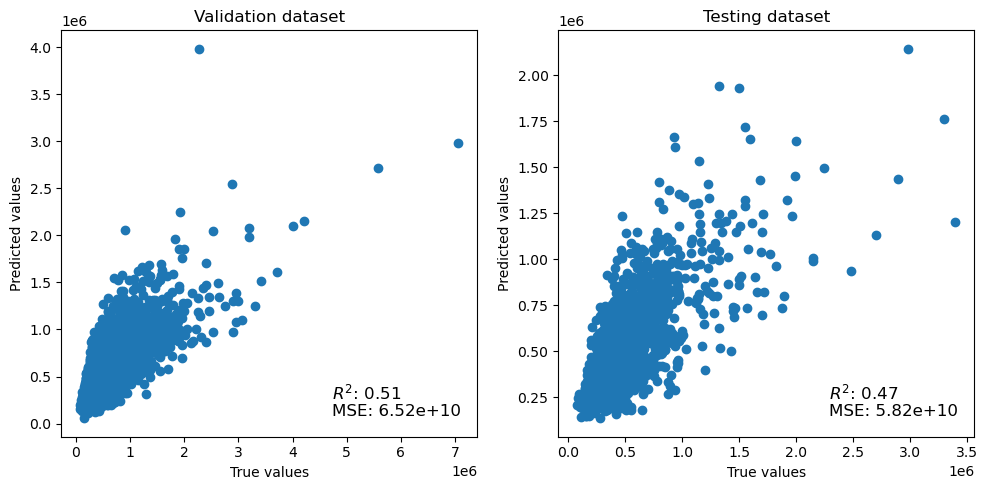

In [ ]:
# Additionally, calculate MSE and plot results
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import numpy as np

y_val_pred = linear_regression_model.predict(x_val_n)
y_test_pred = linear_regression_model.predict(x_test_n)
val_mse = mean_squared_error(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

val_mse_4a = val_mse
test_mse_4a = test_mse
val_score_4a = val_score
test_score_4a = test_score

print("validation MSE: {:.2e}".format(val_mse))
print("testing MSE: {:.2e}".format(test_mse))

# Run the plotting code below to visualize the results

# Plot 1x2 subplots of predictions vs measurements for the validation and testing datasets

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].scatter(y_val, y_val_pred)
axs[0].set_title("Validation dataset")
axs[0].set_xlabel("True values")
axs[0].set_ylabel("Predicted values")
axs[0].text(0.65, 0.05, f"$R^2$: {val_score:.2f}\nMSE: {val_mse:.2e}", transform=axs[0].transAxes, fontsize=12)

axs[1].scatter(y_test, y_test_pred)
axs[1].set_title("Testing dataset")
axs[1].set_xlabel("True values")
axs[1].set_ylabel("Predicted values")
axs[1].text(0.65, 0.05, f"$R^2$: {test_score:.2f}\nMSE: {test_mse:.2e}", transform=axs[1].transAxes, fontsize=12)

plt.tight_layout()

### 4-(b). [4pts] Now fit the Linear Regression model using all the features as input, and report the error improvement over 4-(a).

In [ ]:
# Now use all the features as input
x_train = train_data.drop(['price', 'date', 'id'], axis=1)
y_train = train_data[['price']]

x_test = test_data.drop(['price', 'date', 'id'], axis=1)
y_test = test_data[['price']]

# create a validation set
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=0)

x_train_mean = x_train.mean()
x_train_std = x_train.std()

x_train_n = (x_train - x_train_mean) / x_train_std
x_val_n = (x_val - x_train_mean) / x_train_std
x_test_n = (x_test - x_train_mean) / x_train_std

linear_regression_model = LinearRegression().fit(x_train_n, y_train)

# calculate the $R^2$ of the model predictions
val_score = linear_regression_model.score(x_val_n, y_val)
test_score = linear_regression_model.score(x_test_n, y_test)

print(f"validation $R^2$: {val_score:.2f}")
print(f"testing $R^2$: {test_score:.2f}")

validation $R^2$: 0.69
testing $R^2$: 0.71


validation MSE: 4.12e+10
testing MSE: 3.20e+10


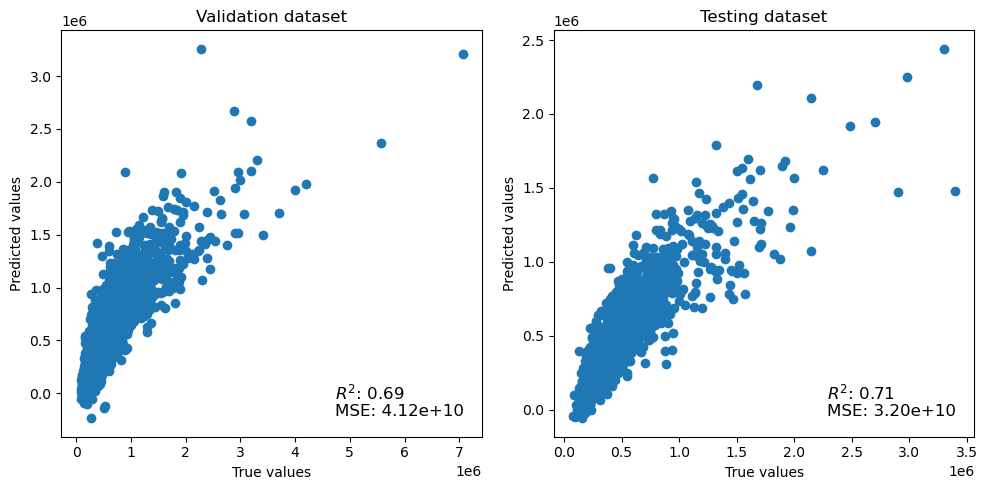

In [ ]:
y_val_pred = linear_regression_model.predict(x_val_n)
y_test_pred = linear_regression_model.predict(x_test_n)
val_mse = mean_squared_error(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

val_mse_4b = val_mse
test_mse_4b = test_mse
val_score_4b = val_score
test_score_4b = test_score

print("validation MSE: {:.2e}".format(val_mse))
print("testing MSE: {:.2e}".format(test_mse))

# Run the plotting code below to visualize the results

# Plot 1x2 subplots of predictions vs measurements for the validation and testing datasets

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].scatter(y_val, y_val_pred)
axs[0].set_title("Validation dataset")
axs[0].set_xlabel("True values")
axs[0].set_ylabel("Predicted values")
axs[0].text(0.65, 0.05, f"$R^2$: {val_score:.2f}\nMSE: {val_mse:.2e}", transform=axs[0].transAxes, fontsize=12)

axs[1].scatter(y_test, y_test_pred)
axs[1].set_title("Testing dataset")
axs[1].set_xlabel("True values")
axs[1].set_ylabel("Predicted values")
axs[1].text(0.65, 0.05, f"$R^2$: {test_score:.2f}\nMSE: {test_mse:.2e}", transform=axs[1].transAxes, fontsize=12)

plt.tight_layout()

In [ ]:
# TODO: calculate change in both MSE and R^2 between the model with only 'sqft_living' and 'bedrooms' and the model with all features

mse_change = test_mse_4b - test_mse_4a
r2_change = test_score_4b - test_score_4a

print(f"MSE change: {mse_change:.2e}")
print(f"R^2 change: {r2_change:.2f}")

MSE change: -2.62e+10
R^2 change: 0.24


### 4-(c). [4pts] Now select 8 features that have the largest absoulute coefficient and use them to fit the Linear Regression model, report the columns you selected, error improvement over 4-(a) and 4-(b) (if any), and possible reasoning.

In [ ]:
# the coef_ represents the coefficients for the linear regression problem
# the intercept_ represents the independent term in the linear model.
print(linear_regression_model.coef_)
print(linear_regression_model.intercept_) # not necessary for the homework but showing for completion

[[-34263.23299357  33358.55420563  83325.88222573   4835.9046792
    3661.05814166  50319.71987344  44334.75509464  16391.04243031
  110905.36043184  77626.26255864  26874.19600398 -78768.46100542
    6405.70946832 -32338.23688275  85207.53922    -29849.75210132
   13951.06768847  -9447.24927214]]
[542800.96933333]


Top 8 features by absolute coefficient: ['grade', 'lat', 'sqft_living', 'yr_built', 'sqft_above', 'waterfront', 'view', 'bedrooms']


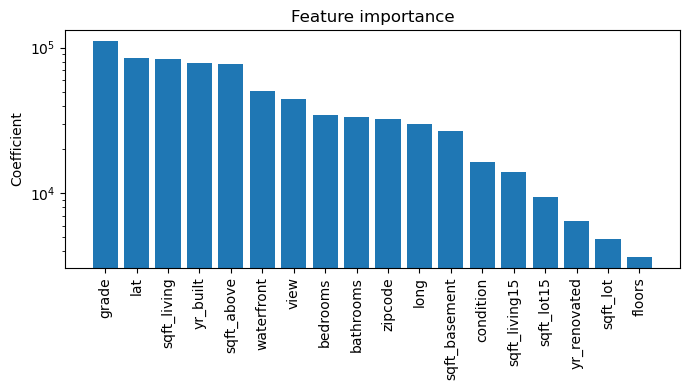

In [ ]:
feature_names = x_train.columns.tolist()
coef_values = linear_regression_model.coef_[0]

sorted_idx = np.argsort(np.abs(coef_values))[::-1]
features = [feature_names[i] for i in sorted_idx]
coefs = [np.abs(coef_values[i]) for i in sorted_idx]

top_8_features = features[:8]
print("Top 8 features by absolute coefficient:", top_8_features)

# bar plot of the coefficients - note this will plot using logscale on y-axis due to high feature weights
plt.figure(figsize=(7, 4))
plt.bar(features, coefs,log=True)
plt.xticks(rotation=90)
plt.ylabel("Coefficient")
plt.title("Feature importance")
plt.tight_layout()

In [ ]:
x_train = train_data[top_8_features]
y_train = train_data[['price']]

x_test = test_data[top_8_features]
y_test = test_data[['price']]

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=0)

x_train_mean = x_train.mean()
x_train_std = x_train.std()

x_train_n = (x_train - x_train_mean) / x_train_std
x_val_n = (x_val - x_train_mean) / x_train_std
x_test_n = (x_test - x_train_mean) / x_train_std

linear_regression_model = LinearRegression().fit(x_train_n, y_train)

# calculate the $R^2$ of the model predictions
val_score = linear_regression_model.score(x_val_n, y_val)
test_score = linear_regression_model.score(x_test_n, y_test)

print(f"validation $R^2$: {val_score:.2f}")
print(f"testing $R^2$: {test_score:.2f}")

validation $R^2$: 0.68
testing $R^2$: 0.69


validation MSE: 4.27e+10
testing MSE: 3.38e+10


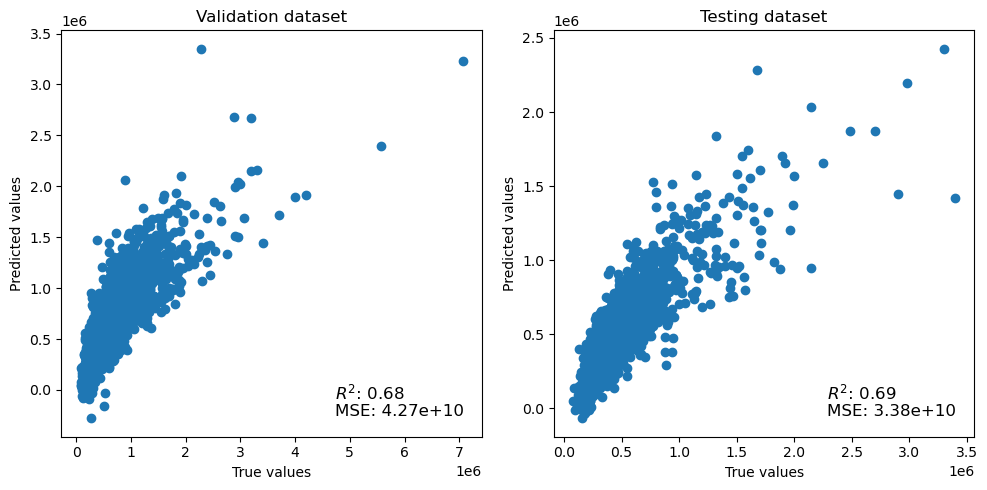

In [ ]:
y_val_pred = linear_regression_model.predict(x_val_n)
y_test_pred = linear_regression_model.predict(x_test_n)
val_mse = mean_squared_error(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

val_mse_4c = val_mse
test_mse_4c = test_mse
val_score_4c = val_score
test_score_4c = test_score

print("validation MSE: {:.2e}".format(val_mse))
print("testing MSE: {:.2e}".format(test_mse))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].scatter(y_val, y_val_pred)
axs[0].set_title("Validation dataset")
axs[0].set_xlabel("True values")
axs[0].set_ylabel("Predicted values")
axs[0].text(0.65, 0.05, f"$R^2$: {val_score:.2f}\nMSE: {val_mse:.2e}", transform=axs[0].transAxes, fontsize=12)

axs[1].scatter(y_test, y_test_pred)
axs[1].set_title("Testing dataset")
axs[1].set_xlabel("True values")
axs[1].set_ylabel("Predicted values")
axs[1].text(0.65, 0.05, f"$R^2$: {test_score:.2f}\nMSE: {test_mse:.2e}", transform=axs[1].transAxes, fontsize=12)

plt.tight_layout()

In [ ]:
# TODO: calculate change in both MSE and R^2 between the model with all features and the model with 8 selected features

mse_change_vs_4a = test_mse_4c - test_mse_4a
r2_change_vs_4a = test_score_4c - test_score_4a
mse_change_vs_4b = test_mse_4c - test_mse_4b
r2_change_vs_4b = test_score_4c - test_score_4b

print(f"vs 4(a) -- MSE change: {mse_change_vs_4a:.2e}, R^2 change: {r2_change_vs_4a:.2f}")
print(f"vs 4(b) -- MSE change: {mse_change_vs_4b:.2e}, R^2 change: {r2_change_vs_4b:.2f}")

vs 4(a) -- MSE change: -2.43e+10, R^2 change: 0.22
vs 4(b) -- MSE change: 1.85e+09, R^2 change: -0.02


### 4-(d). [4pts] Redo 1-(b), this time normalizing the y-variable ('price') prior to fitting. Does prediction performance change? Also, visualize feature weights sorted in descending order of absolute value (do not use log-scale this time). Are the top 8 features the same as when the y-variable is not normalized? Provide your answers to these questions in the PDF.

4(d) with normalized y:
  validation R^2: 0.69, testing R^2: 0.71
  validation MSE: 4.12e+10, testing MSE: 3.20e+10

4(b) without normalized y:
  validation R^2: 0.69, testing R^2: 0.71
  validation MSE: 4.12e+10, testing MSE: 3.20e+10


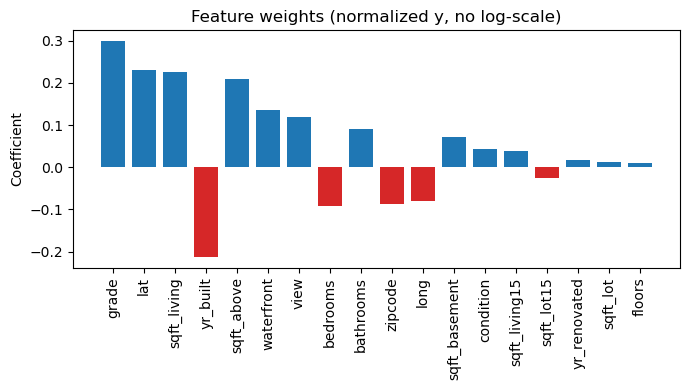


Top 8 features (normalized y):     ['grade', 'lat', 'sqft_living', 'yr_built', 'sqft_above', 'waterfront', 'view', 'bedrooms']
Top 8 features (non-normalized y): ['grade', 'lat', 'sqft_living', 'yr_built', 'sqft_above', 'waterfront', 'view', 'bedrooms']
Same features? True


In [ ]:
x_train = train_data.drop(['price', 'date', 'id'], axis=1)
y_train = train_data[['price']]

x_test = test_data.drop(['price', 'date', 'id'], axis=1)
y_test = test_data[['price']]

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=0)

x_train_mean = x_train.mean()
x_train_std = x_train.std()
x_train_n = (x_train - x_train_mean) / x_train_std
x_val_n = (x_val - x_train_mean) / x_train_std
x_test_n = (x_test - x_train_mean) / x_train_std

y_train_mean = y_train.mean()
y_train_std = y_train.std()
y_train_n = (y_train - y_train_mean) / y_train_std
y_val_n = (y_val - y_train_mean) / y_train_std
y_test_n = (y_test - y_train_mean) / y_train_std

linear_regression_model_4d = LinearRegression().fit(x_train_n, y_train_n)

val_score_4d = linear_regression_model_4d.score(x_val_n, y_val_n)
test_score_4d = linear_regression_model_4d.score(x_test_n, y_test_n)

y_val_pred_n = linear_regression_model_4d.predict(x_val_n)
y_test_pred_n = linear_regression_model_4d.predict(x_test_n)

y_val_pred_4d = y_val_pred_n * y_train_std.values + y_train_mean.values
y_test_pred_4d = y_test_pred_n * y_train_std.values + y_train_mean.values

val_mse_4d = mean_squared_error(y_val, y_val_pred_4d)
test_mse_4d = mean_squared_error(y_test, y_test_pred_4d)

print(f"4(d) with normalized y:")
print(f"  validation R^2: {val_score_4d:.2f}, testing R^2: {test_score_4d:.2f}")
print(f"  validation MSE: {val_mse_4d:.2e}, testing MSE: {test_mse_4d:.2e}")
print(f"\n4(b) without normalized y:")
print(f"  validation R^2: {val_score_4b:.2f}, testing R^2: {test_score_4b:.2f}")
print(f"  validation MSE: {val_mse_4b:.2e}, testing MSE: {test_mse_4b:.2e}")

feature_names_4d = x_train.columns.tolist()
coef_values_4d = linear_regression_model_4d.coef_[0]
sorted_idx_4d = np.argsort(np.abs(coef_values_4d))[::-1]
features_4d = [feature_names_4d[i] for i in sorted_idx_4d]
coefs_4d = [coef_values_4d[i] for i in sorted_idx_4d]

plt.figure(figsize=(7, 4))
colors = ['tab:blue' if c >= 0 else 'tab:red' for c in coefs_4d]
plt.bar(features_4d, coefs_4d, color=colors)
plt.xticks(rotation=90)
plt.ylabel("Coefficient")
plt.title("Feature weights (normalized y, no log-scale)")
plt.tight_layout()
plt.show()

top_8_features_4d = features_4d[:8]
print(f"\nTop 8 features (normalized y):     {top_8_features_4d}")
print(f"Top 8 features (non-normalized y): {top_8_features}")
print(f"Same features? {set(top_8_features_4d) == set(top_8_features)}")

### 4-(e). [4pts] Plot the correlation matrix using the provided function. Turn in the correlation matrix plot and reported your observation.

In [ ]:
!pip install matplotlib --upgrade # make sure your matplotlib version is the latest

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 15.5 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.6
    Uninstalling matplotlib-3.10.6:
      Successfully uninstalled matplotlib-3.10.6


In [ ]:
import matplotlib.pyplot as plt # plotting

def plotCorrelationMatrix(df, graphWidth=10):
    df = df.dropna(axis='columns') # drop columns with NaN
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    if df.shape[1] < 2:
        print(f'No correlation plots shown: The number of non-NaN or constant columns ({df.shape[1]}) is less than 2')
        return
    corr = df.corr()
    plt.figure(num=None, figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    corrMat = plt.matshow(corr, fignum = 1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.show()

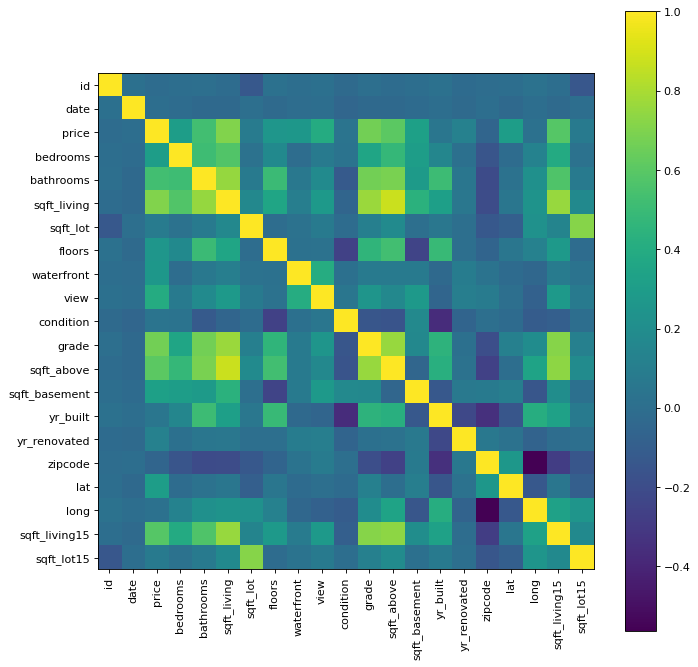

In [ ]:
plotCorrelationMatrix(train_data)

For 4-(f,g,h), you are aksed to derive the close-form solution of linear regression, please refers to the handout and answer them on the pdf.

## 5. [5pts] Support Vector Machine (10%).

For 5-(a)~(c)~, please show your calculation steps and the final answer in the pdf